# Problem Statement

## To Predict the Heart Disease of Patient

In [99]:
#Importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [100]:
df = pd.read_csv("heart.csv") #loading the data

# Basic Checks

In [101]:
# Basic check of the dataset
df.head()  # what features are here and head columns

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [102]:
df.tail() # checking end of data how many rows present

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [103]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [104]:
df.shape # The shape of the data

(918, 12)

In [105]:
df.describe()  # only numerical columns describe

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [106]:
df.info() # checking the data information like 
# how many rows and columns present
# Any missing values and the Datatyes of the column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [107]:
# check nulls values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [108]:
# check duplicates rows & columns values
df.duplicated().sum()

np.int64(0)

In [109]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [110]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [111]:
df['Age'].min(), df['Age'].max()

(28, 77)

# Domain Analysis

# Age
- Domain: Numeric (years).
- Range: Typically 28–77 in heart disease datasets, but conceptually 0–120.
- Role: Risk factor — older age increases likelihood of heart disease.
# Sex
- Domain: Categorical (Male/Female).
- Values: Often encoded as 0 = Female, 1 = Male.
- Role: Biological differences affect risk; men generally have higher incidence.

# ChestPainType
- Domain: Categorical.
- Values:
- TA = Typical Angina
- ATA = Atypical Angina
- NAP = Non-Anginal Pain
- ASY = Asymptomatic
- Role: Key diagnostic indicator of coronary artery disease.

🩺 Vital Signs & Lab Results
- RestingBP (Resting Blood Pressure)
- Domain: Numeric (mmHg).
- Range: Typically 90–200.
- Role: Hypertension is a major risk factor.
- Cholesterol
- Domain: Numeric (mg/dL).
- Range: Usually 100–600.
- Role: High cholesterol contributes to plaque buildup in arteries.
- FastingBS (Fasting Blood Sugar)
- Domain: Binary (0 or 1).
- Values:
- 0 = Fasting blood sugar < 120 mg/dL
- 1 = Fasting blood sugar ≥ 120 mg/dL
- Role: Indicates diabetes risk, which correlates with heart disease.

⚡ Diagnostic Tests
- RestingECG (Resting Electrocardiogram Results)
- Domain: Categorical.
- Values:
- Normal
- ST = ST-T wave abnormality
- LVH = Left Ventricular Hypertrophy
- Role: Detects electrical abnormalities in heart function.
- MaxHR (Maximum Heart Rate Achieved)
- Domain: Numeric (beats per minute).
- Range: Typically 60–202.
- Role: Lower maximum HR may indicate poor cardiovascular fitness.
- ExerciseAngina
- Domain: Binary (Yes/No).
- Values: Y = Yes, N = No.
- Role: Angina induced by exercise is a strong predictor of heart disease.
- Oldpeak
- Domain: Numeric (float).
- Range: 0–6.2 (depression of ST segment).
- Role: Measures ST depression induced by exercise relative to rest; higher values suggest ischemia.
- ST_Slope
- Domain: Categorical.
- Values:
- Up = Upsloping
- Flat = Flat
- Down = Downsloping
- Role: Shape of ST segment during exercise; downsloping is most associated with heart disease.

🩻 Target Variable
- HeartDisease
- Domain: Binary (0 or 1).
- Values:
- 0 = No heart disease
- 1 = Heart disease present
- Role: Prediction target for classification models.


# EDA

In [112]:
# we are checking in HeartDisease values in (0-no heart disease) & (1-have heart disease) format
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

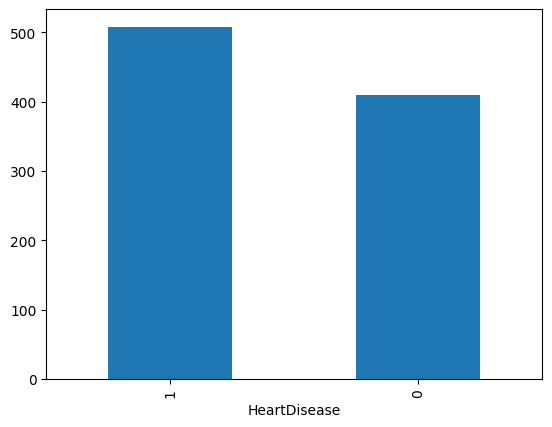

In [113]:
df["HeartDisease"].value_counts().plot(kind = "bar")
plt.show()

##### A Heart Disease chart with two bars
##### One for "0"(no heart disease)
##### Other for "1"(heart disease)
##### The bar heights show how many people fall into each group. compare to 0 & 1 we are see many people has heart disease problem.

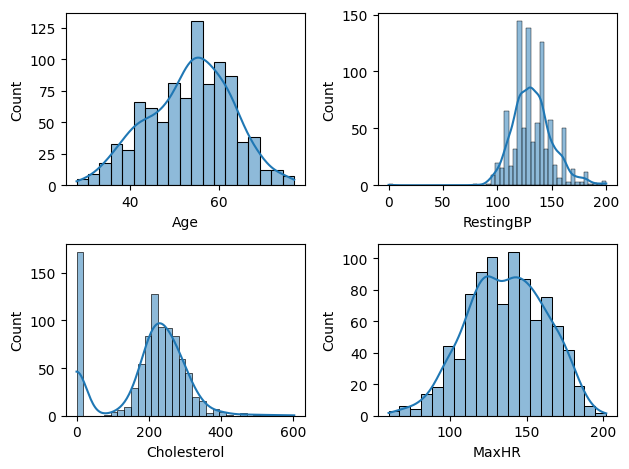

In [114]:
def plotting(var,num):
    plt.subplot(2,2,num)   # Numerical plots
    sns.histplot(df[var],kde = True)

plotting("Age",1)
plotting("RestingBP",2)
plotting("Cholesterol",3)
plotting("MaxHR",4)
plt.tight_layout()

##### 1. Shape- Approximately normal (bell-shaped), centered around 55 years.
#####  Insight- Most individuals in the dataset are middle-aged. This suggests the study or dataset likely targets adults at higher risk for cardiovascular or age-related conditions.

##### 2. Shape- Slightly left-skewed, (bell-shaped), centred around 120 mmHg.
##### Insight- 120 mmHg is considered normal resting BP, so the majority fall within healthy range. The skew indicates a subset with elevated BP, possibly hypertensive individuals.

##### 3. Shape- Highly right-skewed, peak near 0, long tail toward high values.
##### No, a person cannot have a resting blood pressure of exactly zero, as even after the heart stops beating, The right-skewed tail suggests some individuals have very high cholesterol, which could be a risk factor for heart disease. Worth checking for data quality or outliers.

##### 4. Shape- Roughly normal, centered around 140 bpm.
##### Insight- This is typical for stress test or exercise data. A normal distribution implies consistent measurement across the population, and 140 bpm aligns with expected max HR for middle-aged adults





In [115]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [116]:
chol_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,chol_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [117]:
chol_mean

np.float64(244.6353887399464)

In [118]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
101      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [119]:
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [120]:
resting_bp_mean

np.float64(132.54089422028352)

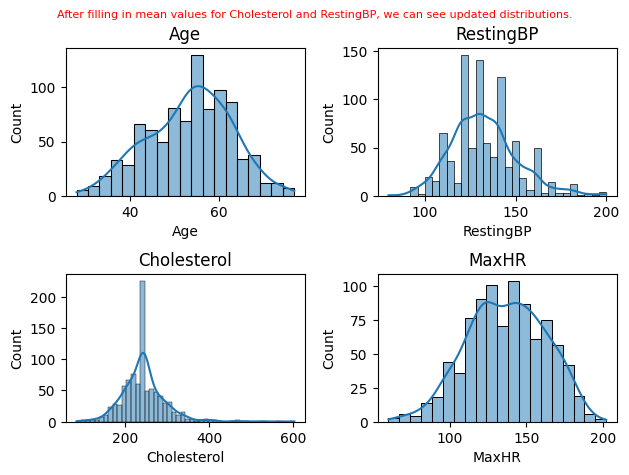

In [121]:
def plotting(var, num):
    plt.subplot(2, 2, num)   # canvas method
    sns.histplot(df[var], kde=True)
    plt.title(var)  # optional: add individual titles per subplot

plotting("Age", 1)
plotting("RestingBP", 2)
plotting("Cholesterol", 3)
plotting("MaxHR", 4)

plt.tight_layout()
plt.suptitle(
    "After filling in mean values for Cholesterol and RestingBP, we can see updated distributions.",
    fontsize=8,
    color='red'
)
plt.subplots_adjust(top=0.9)  # adjust space so the suptitle fits

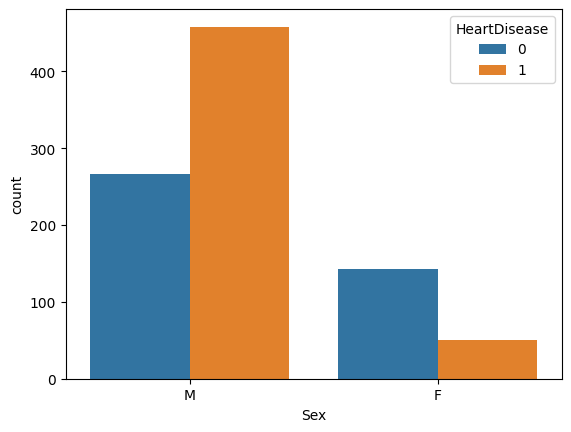

In [122]:
sns.countplot(x = df['Sex'],hue = df['HeartDisease'])
plt.show()

### Males -
##### The orange bar (HeartDisease = 1) is taller than the blue bar.
##### Insight: A higher number of males in the dataset have heart disease compared to those who don’t.

### Females -
##### The Blue bar (HeartDisease = 0) is taller than the orange bar.
##### Insight: Most females in the dataset don't have heart disease.





In [123]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [124]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

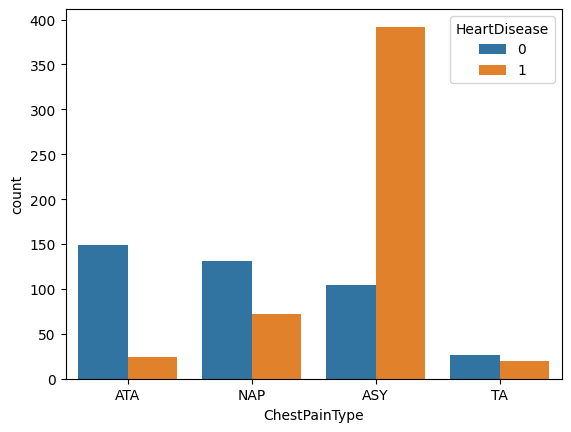

In [125]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])
plt.show()

                           chestpainType with HeartsDisease
##### ATA (Atypical Angina) -- Higher counts of individuals without HeartDisease (blue bars).

##### NAP (Non-Anginal Pain) -- NAP is less associated with heart disease in this dataset.

##### ASY (Asymptomatic) -- Highest count of HeartDisease cases (orange bars). people with ASY chest pain are more likely to have heart disease.

##### TA (Typical Angina) -- Lowest overall counts in both categories.




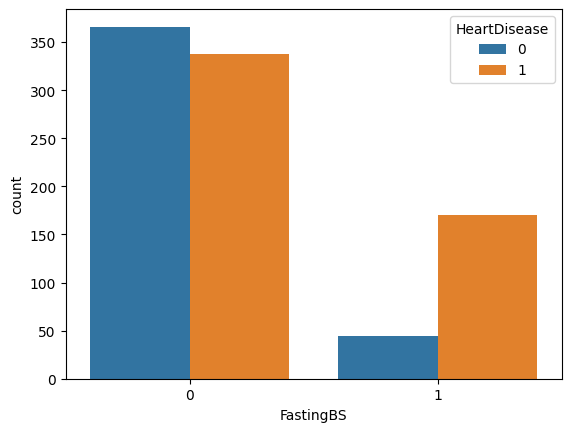

In [126]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'])
plt.show()

#####  FastingBS = 0 (Normal Blood Sugar) -- if fastingbs is 0 then they are eqaul to the heart disease.

#####  FastingBS = 1 (High Blood Sugar > 120 mg/dL) -- if fastingbs is 1 then they are getting heartdisease risk.



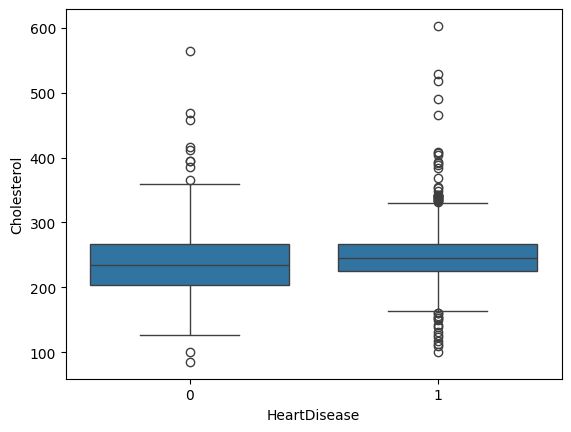

In [127]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)
plt.show()

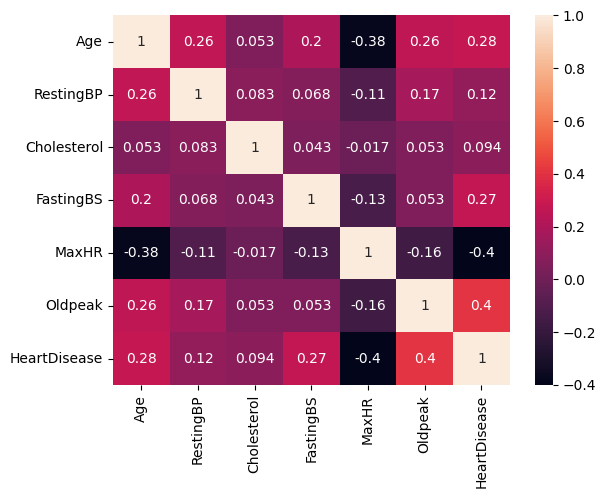

In [128]:
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.show()

# Data preprocessing and cleaning

In [129]:
df_clean = df.copy()

In [130]:
df_clean

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [131]:
df_clean.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [132]:
df_clean['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

# One-hot encoding

In [133]:
df_clean = pd.get_dummies(df_clean, columns=['ChestPainType'], dtype=int)

In [134]:
df_clean

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,M,140.0,289.0,0,Normal,172,N,0.0,Up,0,0,1,0,0
1,49,F,160.0,180.0,0,Normal,156,N,1.0,Flat,1,0,0,1,0
2,37,M,130.0,283.0,0,ST,98,N,0.0,Up,0,0,1,0,0
3,48,F,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,1,0,0,0
4,54,M,150.0,195.0,0,Normal,122,N,0.0,Up,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,110.0,264.0,0,Normal,132,N,1.2,Flat,1,0,0,0,1
914,68,M,144.0,193.0,1,Normal,141,N,3.4,Flat,1,1,0,0,0
915,57,M,130.0,131.0,0,Normal,115,Y,1.2,Flat,1,1,0,0,0
916,57,F,130.0,236.0,0,LVH,174,N,0.0,Flat,1,0,1,0,0


In [135]:
df['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

# Label Encoding

In [136]:
df_clean['RestingECG'] = df_clean['RestingECG'].replace({"Normal":0,"LVH":1,"ST":2})  #Normal = 0, LVH =1, ST = 2
df_clean['ExerciseAngina'] = df_clean['ExerciseAngina'].replace({"N":0,"Y":1}) # N = 0, Y =1
df_clean['ST_Slope'] = df_clean['ST_Slope'].replace({"Flat":0,"Up":1,"Down":2})  # Flat = 0, Up = 1, Down = 2
df_clean['Sex'] = df_clean['Sex'].replace({"M":0,"F":1})   # Male = 0 & Female = 1

In [137]:
df_clean 

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,0,140.0,289.0,0,0,172,0,0.0,1,0,0,1,0,0
1,49,1,160.0,180.0,0,0,156,0,1.0,0,1,0,0,1,0
2,37,0,130.0,283.0,0,2,98,0,0.0,1,0,0,1,0,0
3,48,1,138.0,214.0,0,0,108,1,1.5,0,1,1,0,0,0
4,54,0,150.0,195.0,0,0,122,0,0.0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110.0,264.0,0,0,132,0,1.2,0,1,0,0,0,1
914,68,0,144.0,193.0,1,0,141,0,3.4,0,1,1,0,0,0
915,57,0,130.0,131.0,0,0,115,1,1.2,0,1,1,0,0,0
916,57,1,130.0,236.0,0,1,174,0,0.0,0,1,0,1,0,0


# Model Evaluation


In [142]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets, linear_model, metrics

In [143]:
# we Seperate the features and target 
X = df_clean.drop('HeartDisease',axis = 1)
y = df_clean['HeartDisease']

In [144]:
# Spliting the data for Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Feature Scaling 

In [145]:
# After splitting
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LogisticRegression Model

In [146]:
# using LogisticRegression model
model_LR = LogisticRegression(max_iter=10000, random_state=0)
model_LR.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=10000, random_state=0)

In [147]:
y_pred_LR = model_LR.predict(X_test_scaled)

In [148]:
y_pred_LR

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])

In [149]:
# Evaluate the Model
print(f"\033[91mLogisticRegression model accuracy: {metrics.accuracy_score(y_test, y_pred_LR) * 100:.2f}%\033[0m")
print("Classification Report:\n", classification_report(y_test, y_pred_LR))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_LR))

LogisticRegression model accuracy: 85.87%
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184


Confusion Matrix:
 [[68  9]
 [17 90]]


# GaussianNB Model

In [150]:
#using GaussianNB model
model_NB = GaussianNB()
model_NB.fit(X_train,y_train)

GaussianNB()

In [151]:
y_pred_NB = model_NB.predict(X_test)
y_pred_NB

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])

In [152]:
# Evaluate the Model
# ANSI escape code for red text: \033[91m
print(f"\033[91mGaussianNB model accuracy: {metrics.accuracy_score(y_test, y_pred_NB) * 100:.2f}%\033[0m")
print("Classification Report:\n", classification_report(y_test, y_pred_NB))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_NB))

GaussianNB model accuracy: 82.07%
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.80        77
           1       0.87      0.81      0.84       107

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184


Confusion Matrix:
 [[64 13]
 [20 87]]


# DecisionTreeClassifier Model

In [153]:
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [154]:
y_pred_DT = model_DT.predict(X_test_scaled)
y_pred_DT

array([1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1])

In [155]:
# Evaluate the Model
print(f"\033[91mDecisionTree model accuracy: {metrics.accuracy_score(y_test, y_pred_DT) * 100:.2f}%\033[0m")
print("Classification Report:\n", classification_report(y_test, y_pred_DT))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_DT))

DecisionTree model accuracy: 78.80%
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.84      0.77        77
           1       0.87      0.75      0.80       107

    accuracy                           0.79       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.79      0.79       184


Confusion Matrix:
 [[65 12]
 [27 80]]


# KNN Model

In [156]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [157]:
y_pred_knn = model_knn.predict(X_test_scaled)
y_pred_knn

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1])

In [158]:
# Evaluate the Model
print(f"\033[91mKNN model accuracy: {metrics.accuracy_score(y_test, y_pred_knn) * 100:.2f}%\033[0m")
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN model accuracy: 85.87%
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184


Confusion Matrix:
 [[68  9]
 [17 90]]


# SVM model

In [159]:
model_svm = SVC()
model_svm.fit(X_train_scaled,y_train)

SVC()

In [160]:
y_pred_svm = model_svm.predict(X_test_scaled)
y_pred_svm

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])

In [161]:
# Evaluate the Model
print(f"\033[91mSVM model accuracy: {metrics.accuracy_score(y_test, y_pred_svm) * 100:.2f}%\033[0m")
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM model accuracy: 87.50%
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184


Confusion Matrix:
 [[67 10]
 [13 94]]


# insights of models

# Hyperparameter Tuning on svm model

In [165]:
# Import libraries
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Define SVM model
svm = SVC()

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000, 10000],
    'gamma': [1e-4, 1e-3, 1e-2, 0.1, 1, 'scale', 'auto'],
    'kernel': ['linear', 'rbf', 'poly']
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,             # 5-fold cross-validation
    scoring='accuracy',
    verbose=2,
    n_jobs=-1         # Use all CPU cores
)

# Fit the model
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best estimator
best_svm = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_svm.predict(X_test_scaled)
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 147 candidates, totalling 735 fits
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [166]:
import joblib

# Save the trained SVM model
joblib.dump(best_svm, 'svc_heart.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the column names
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']